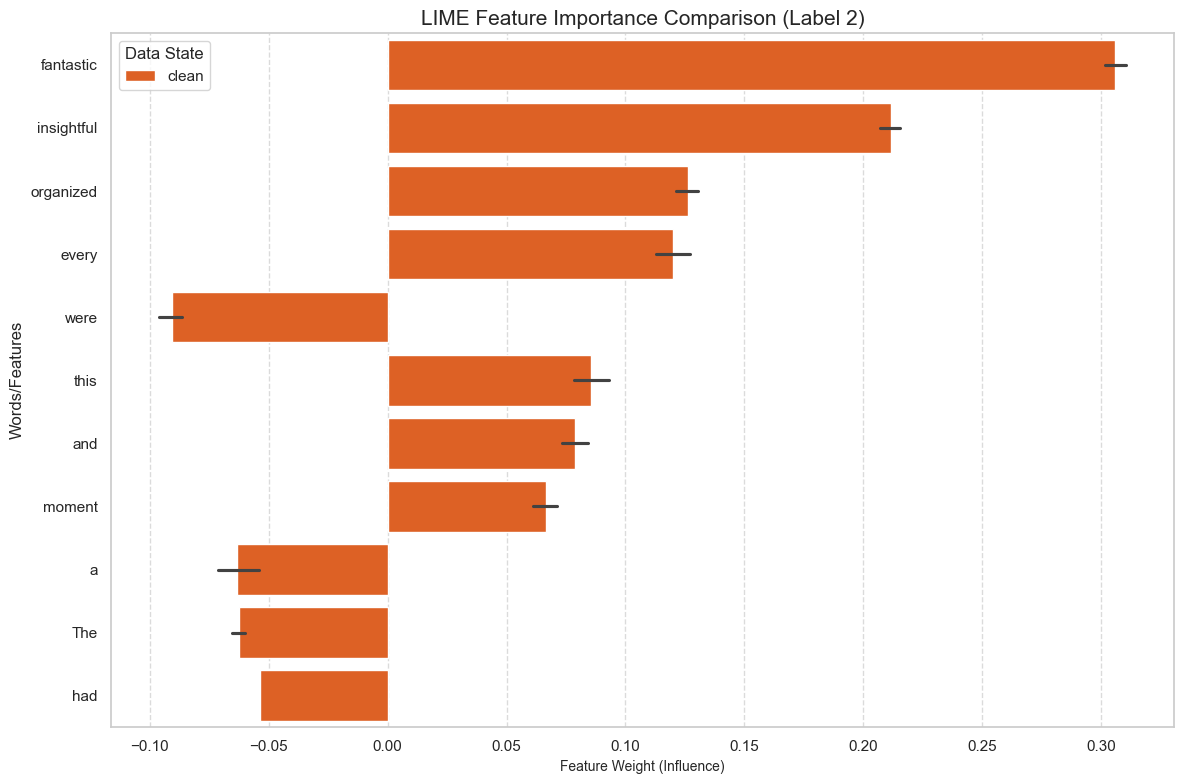

In [95]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
file_path = "/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/lime_stability_experiment.csv"
df_clean = pd.read_csv(file_path)

# Filter for the specific label you want to visualize (e.g., Label 2)
# and take the most recent run if you have multiple seeds/samples
target_label = 2
plot_df = df_clean[df_clean['label'] == target_label].copy()

# Create the Visualization
plt.figure(figsize=(12, 8))

# We use a barplot to compare 'weight' across different 'features'
# hue='data_state' will put Clean and Biased bars side-by-side
sns.barplot(
    data=plot_df,
    x='weight',
    y='feature',
    hue='data_state',
    palette={'clean':'#fb5607'} # Blue for clean, Red for biased
)

plt.title(f'LIME Feature Importance Comparison (Label {target_label})', fontsize=15)
plt.xlabel('Feature Weight (Influence)', fontsize=10)
plt.ylabel('Words/Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Data State')
plt.savefig("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/results/lime_stability_experiment.png",bbox_inches='tight')
plt.tight_layout()
plt.show()


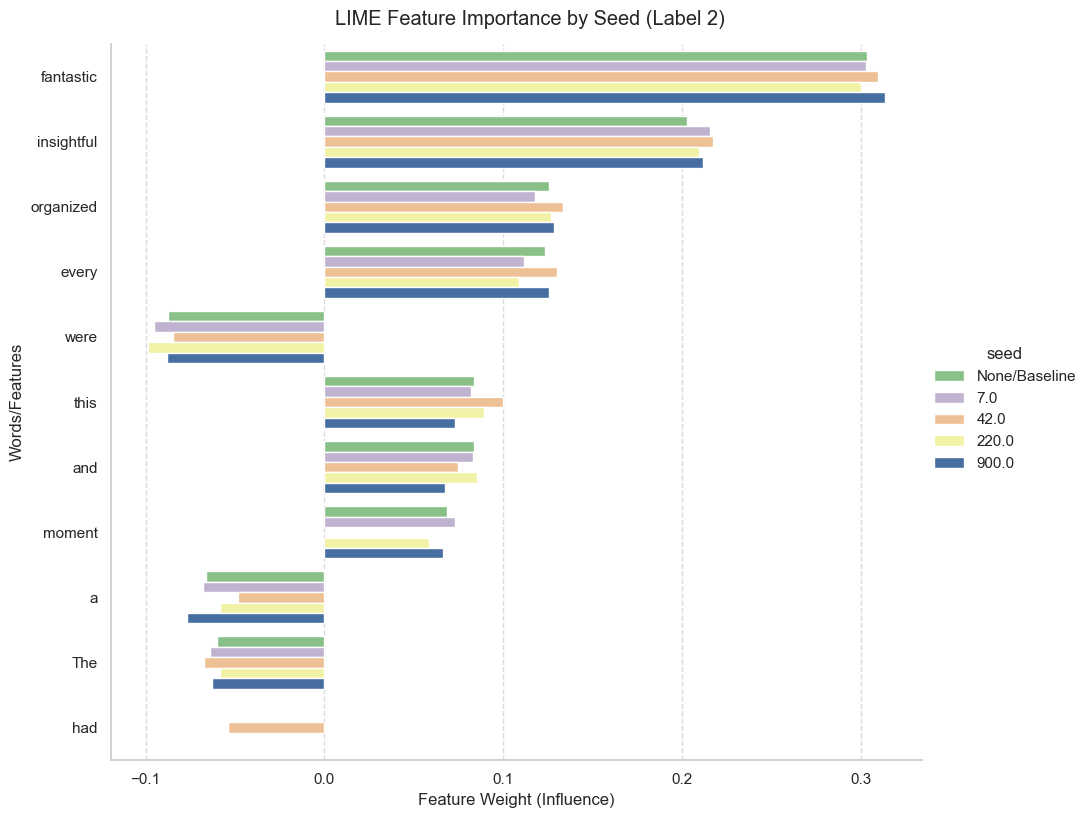

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for the specific label
target_label = 2
# Ensure type consistency (e.g., if label was saved as a string)
plot_df = df_clean[df_clean['label'].astype(str) == str(target_label)].copy()

if plot_df.empty:
    print(f"Error: No data found for label {target_label}. Check your CSV values.")
else:
    # Handle the 'None' seed visually
    # Replacing actual None/NaN with a string so Seaborn can categoricalize it
    plot_df['seed'] = plot_df['seed'].fillna('None/Baseline').astype(str)

    custom_colors = ["#84a98c", "#fb5607", "#003f88", "#d90429", "#F333FF"]
    # Create the Visualization
    g = sns.catplot(
        data=plot_df,
        kind='bar',
        x='weight',
        y='feature',
        hue='seed',  # Seeds are now the side-by-side bars
        height=8,
        aspect=1.2,
        palette= 'Accent' # Blue for clean, Red for biased
, # Using a standard palette for multiple seeds
        legend_out=True,
        #linestyle='--',
    )
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    g.fig.suptitle(f'LIME Feature Importance by Seed (Label {target_label})', y=1.02)
    g.set_axis_labels('Feature Weight (Influence)', 'Words/Features')
    plt.savefig("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/results/lime_stability_experiment_across_seeds.png",bbox_inches='tight')
    plt.show()

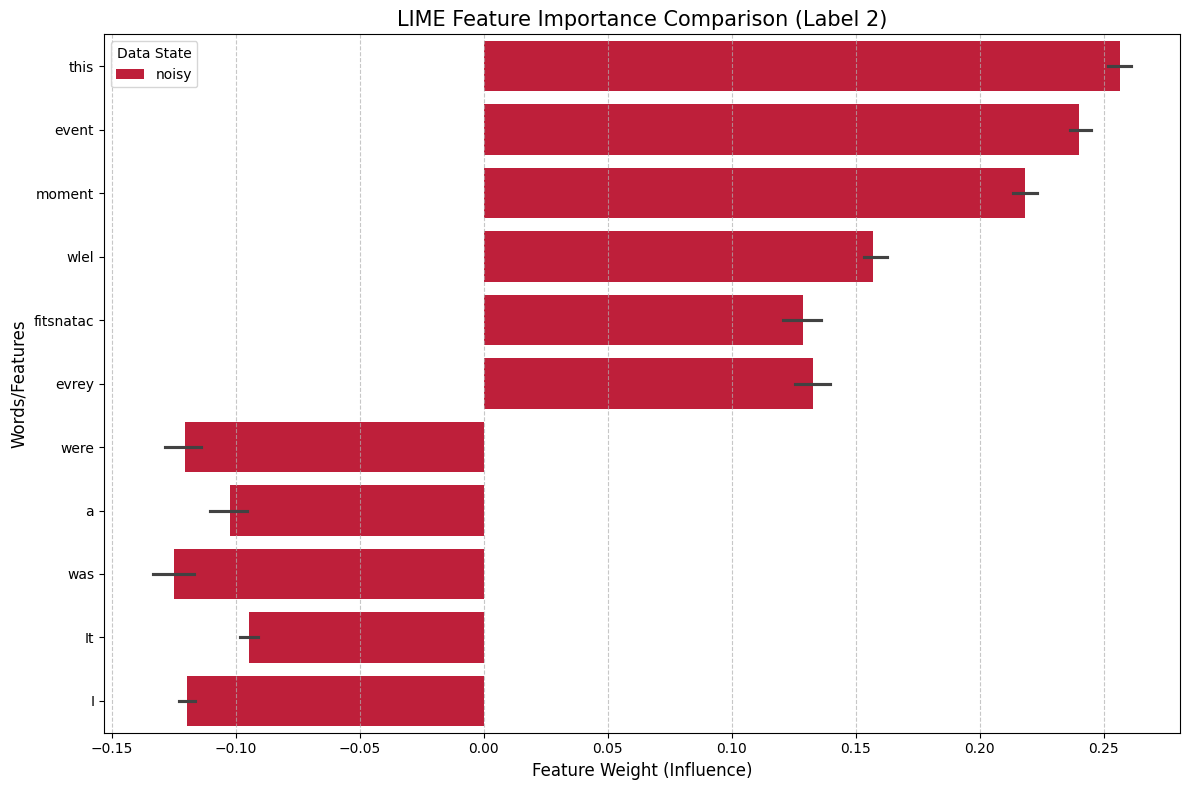

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
file_path = "/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/perturb_lime_stability_experiment.csv"
df_noisy = pd.read_csv(file_path)

# Filter for the specific label you want to visualize (e.g., Label 2)
# and take the most recent run if you have multiple seeds/samples
target_label = 2
plot_noisy_df = df_noisy[df_noisy['label'] == target_label].copy()

# Create the Visualization
plt.figure(figsize=(12, 8))

# We use a barplot to compare 'weight' across different 'features'
# hue='data_state' will put Clean and Biased bars side-by-side
sns.barplot(
    data=plot_noisy_df,
    x='weight',
    y='feature',
    hue='data_state',
    palette={'noisy': '#d90429', 'biased': '#450920'} # Blue for clean, Red for biased
)

plt.title(f'LIME Feature Importance Comparison (Label {target_label})', fontsize=15)
plt.xlabel('Feature Weight (Influence)', fontsize=12)
plt.ylabel('Words/Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Data State')

plt.savefig("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/results/perturb_lime_stability_experiment.png",bbox_inches='tight')

plt.tight_layout()
plt.show()


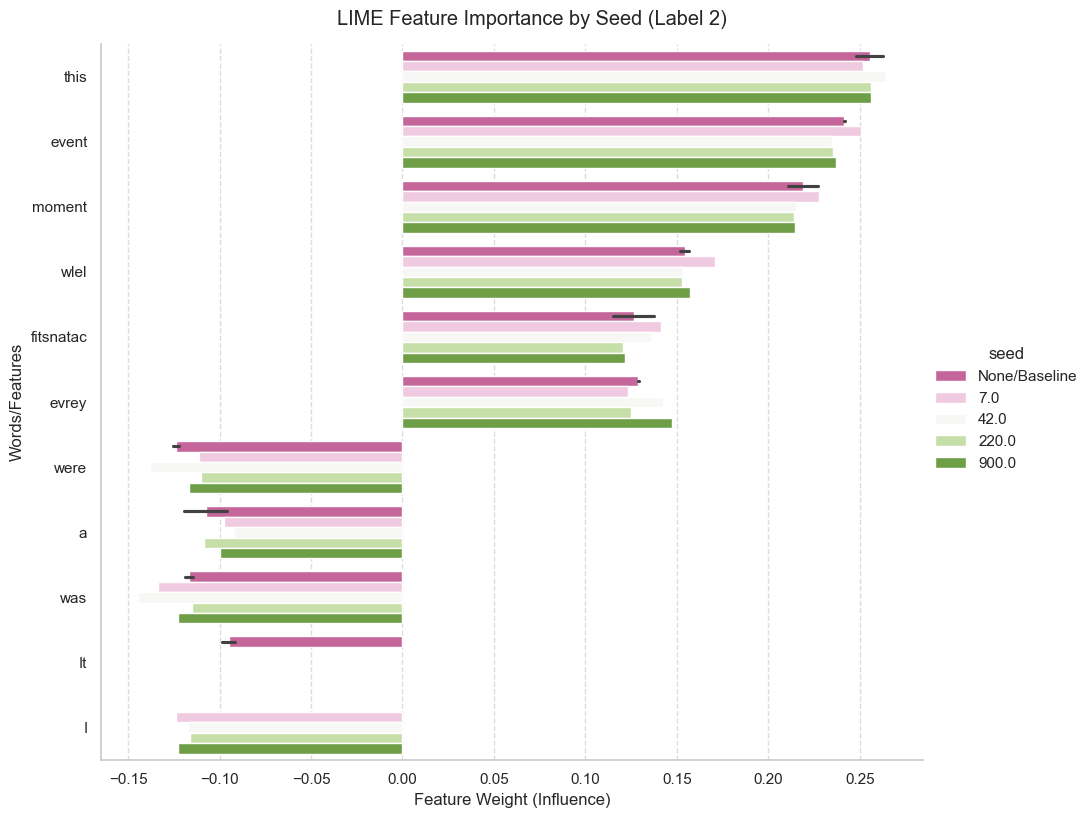

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for the specific label
target_label = 2
# Ensure type consistency (e.g., if label was saved as a string)
plot_noisy_df= df_noisy[df_noisy['label'].astype(str) == str(target_label)].copy()

if plot_df.empty:
    print(f"Error: No data found for label {target_label}. Check your CSV values.")
else:
    # Handle the 'None' seed visually
    # Replacing actual None/NaN with a string so Seaborn can categoricalize it
    plot_noisy_df['seed'] = plot_noisy_df['seed'].fillna('None/Baseline').astype(str)

    custom_colors = ["#003049", "#669bbc", "#fdf0d5", "#450920", "#F333FF"]
    # Create the Visualization
    g = sns.catplot(
        data=plot_noisy_df,
        kind='bar',
        x='weight',
        y='feature',
        hue='seed',  # Seeds are now the side-by-side bars
        height=8,
        aspect=1.2,
        palette= 'PiYG' # Blue for clean, Red for biased
, # Using a standard palette for multiple seeds
        legend_out=True,
    )
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    g.fig.suptitle(f'LIME Feature Importance by Seed (Label {target_label})', y=1.02)
    g.set_axis_labels('Feature Weight (Influence)', 'Words/Features')
    plt.savefig("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/results/noisy_lime_stability_experiment_across_seeds.png",bbox_inches='tight')
    plt.show()

## LIME Sobol evaluation

<Figure size 1400x800 with 0 Axes>

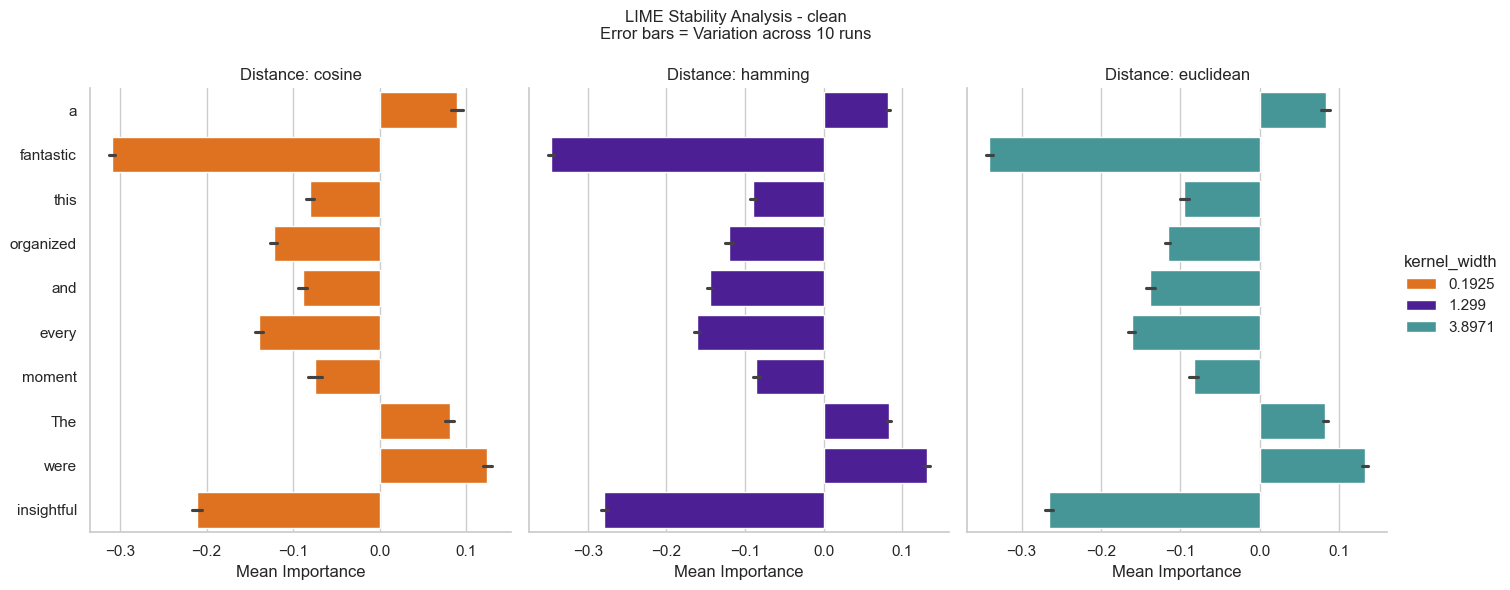

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df_sobol = pd.read_csv("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/lime_sobol_sampling_kernel_results.csv")

# Calculate Absolute Importance for ranking
df_sobol['abs_importance'] = df_sobol['importance'].abs()

# Get top 10 most influential words overall
top_words = df_sobol.groupby('word')['abs_importance'].mean().nlargest(10).index
df_plot = df_sobol[df_sobol['word'].isin(top_words)]

# Create a FacetGrid to compare Metrics
plt.figure(figsize=(14, 8))

sns.set_theme(style="whitegrid")
colors = ['#ff6d00','#480ca8','#38a3a5']
# Use a PointPlot or BarPlot with error bars to show stability
g = sns.catplot(
    data=df_plot,
    kind="bar",
    x="importance",
    y="word",
    hue="kernel_width", # Compare metrics side-by-side
    col="metric", # Give each metric its own subplot
    errorbar="sd", # SHOWS STABILITY: Standard Deviation of the 10 iterations
    palette= colors,
    height=6,
    aspect=0.8,
    sharex=False
)

g.set_axis_labels("Mean Importance", "")
g.set_titles("Distance: {col_name}")
plt.subplots_adjust(top=0.85)
g.fig.suptitle("LIME Stability Analysis - clean\nError bars = Variation across 10 runs", fontsize=12)
plt.savefig("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/results/lime_sobol_stability_experiment.png")
plt.show()



<Figure size 1400x800 with 0 Axes>

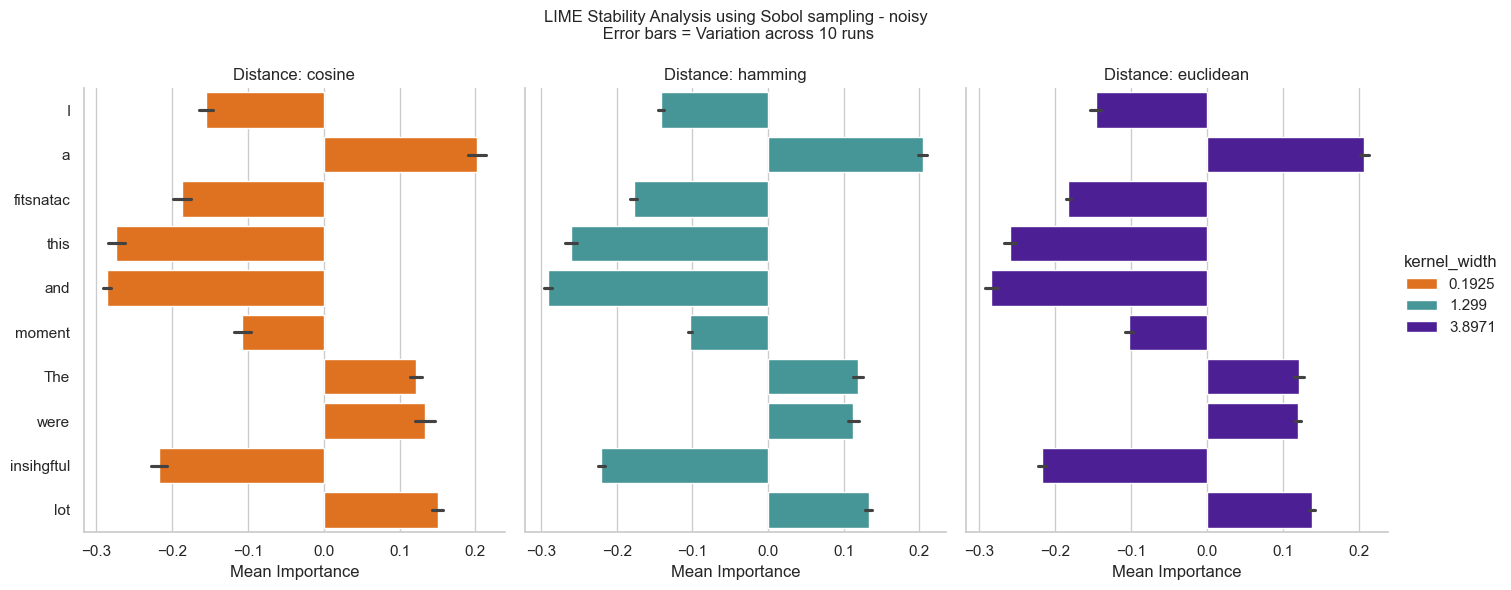

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load  data
df_sobol = pd.read_csv("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/lime_perturb_sobol_sampling_kernel_results.csv")

# Calculate Absolute Importance for ranking
df_sobol['abs_importance'] = df_sobol['importance'].abs()

# Get top 10 most influential words overall
top_words = df_sobol.groupby('word')['abs_importance'].mean().nlargest(10).index
df_plot = df_sobol[df_sobol['word'].isin(top_words)]

# Create a FacetGrid to compare Metrics
plt.figure(figsize=(14, 8))

sns.set_theme(style="whitegrid")
colors = ['#ff6d00','#38a3a5','#480ca8']

# Use a PointPlot or BarPlot with error bars to show stability
g = sns.catplot(
    data=df_plot,
    kind="bar",
    x="importance",
    y="word",
    hue="kernel_width", # Compare metrics side-by-side
    col="metric", # Give each metric its own subplot
    errorbar="sd", # SHOWS STABILITY: Standard Deviation of the 10 iterations
    palette=colors,
    height=6,
    aspect=0.8,
    sharex=False
)

g.set_axis_labels("Mean Importance", "")
g.set_titles("Distance: {col_name}")
plt.subplots_adjust(top=0.85)
g.fig.suptitle("LIME Stability Analysis using Sobol sampling - noisy\n Error bars = Variation across 10 runs", fontsize=12)

plt.savefig("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/results/perturb_lime_sobol_stability_experiment.png")
plt.show()



## LHS Sampling clean vs noise

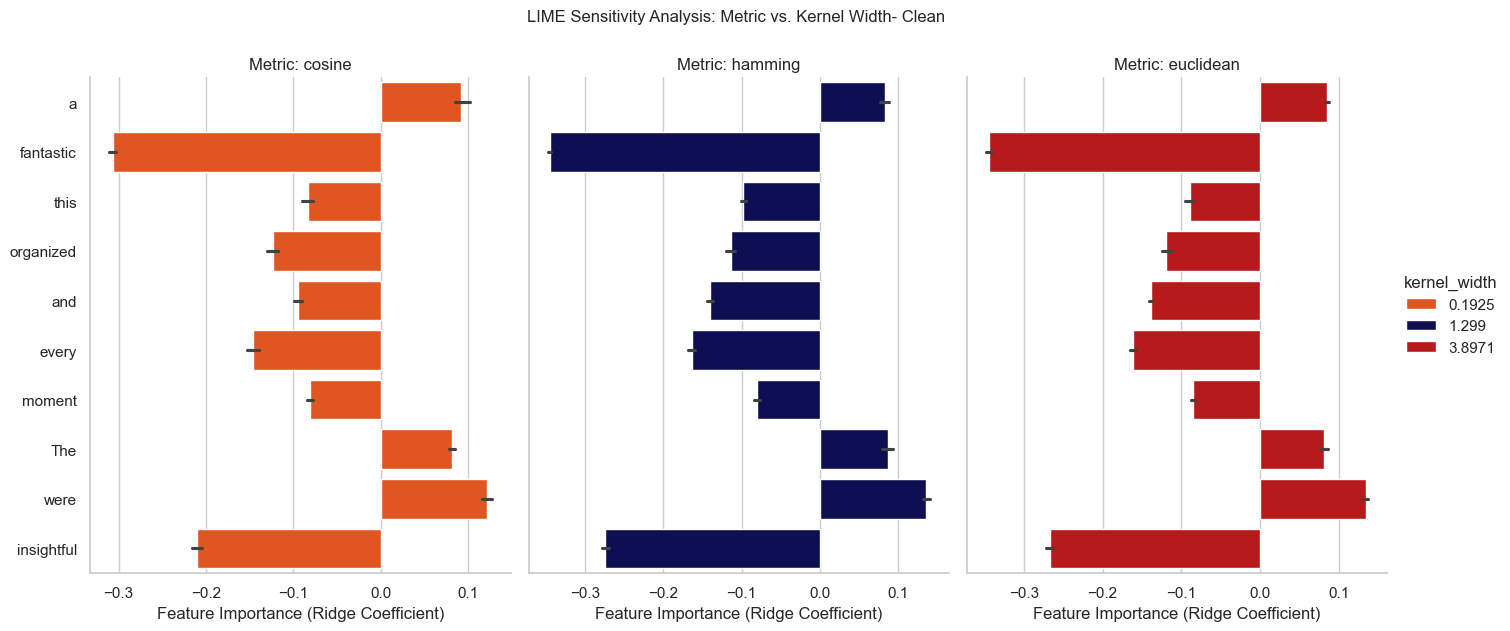

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df_lhs = pd.read_csv('/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/lime_lhs_sampling_kernel_results.csv')

# Filtering for Readability
# LIME can generate many words. We'll pick the top 10 most influential
# words based on average absolute importance to keep the plot clean.
top_words = (
    df_lhs.groupby('word')['importance']
    .apply(lambda x: x.abs().mean())
    .sort_values(ascending=False)
    .head(10)
    .index
)
df_filtered = df_lhs[df_lhs['word'].isin(top_words)]

# Create the Visualization
# We use 'catplot' to create a grid: one column per Metric
sns.set_theme(style="whitegrid")
colors = ['#ff4800','#03045e','#d00000']
g = sns.catplot(
    data=df_filtered,
    kind="bar",
    x="importance",
    y="word",
    hue="kernel_width",
    col="metric",
    palette=colors,
    height=6,
    aspect=0.8,
    sharex=False # Allows each metric to show its own scale if they vary wildly
)

# Customizing Labels and Titles
g.set_axis_labels("Feature Importance (Ridge Coefficient)", "")
g.set_titles("Metric: {col_name}")
g.fig.suptitle("LIME Sensitivity Analysis: Metric vs. Kernel Width- Clean", y=1.05, fontsize=12)
plt.savefig("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/results/lhs_stability_experiment.png")
plt.show()

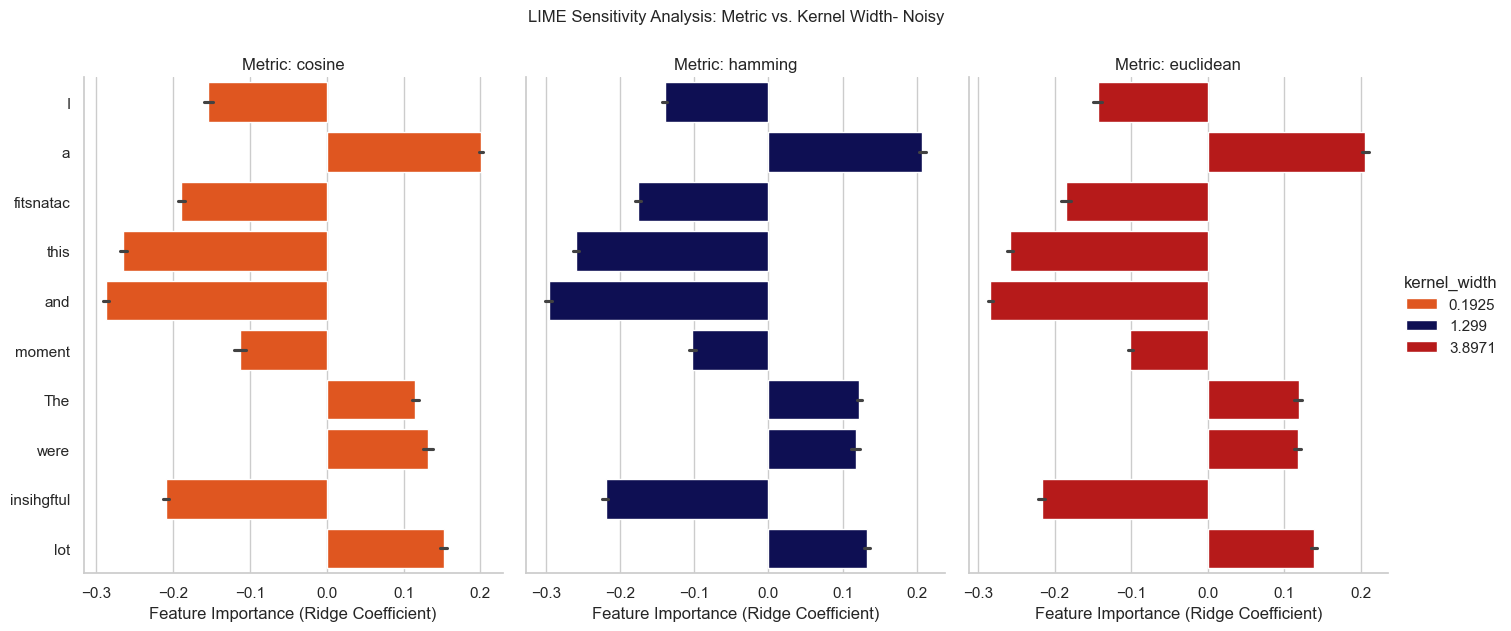

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df_lhs = pd.read_csv('/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/lime_perturb_lhs_sampling_kernel_results.csv')

# Filtering for Readability
# LIME can generate many words. We'll pick the top 10 most influential
# words based on average absolute importance to keep the plot clean.
top_words = (
    df_lhs.groupby('word')['importance']
    .apply(lambda x: x.abs().mean())
    .sort_values(ascending=False)
    .head(10)
    .index
)
df_filtered = df_lhs[df_lhs['word'].isin(top_words)]

# Create the Visualization
# We use 'catplot' to create a grid: one column per Metric
sns.set_theme(style="whitegrid")
colors = ['#ff4800','#03045e','#d00000']
g = sns.catplot(
    data=df_filtered,
    kind="bar",
    x="importance",
    y="word",
    hue="kernel_width",
    col="metric",
    palette=colors,
    height=6,
    aspect=0.8,
    sharex=False # Allows each metric to show its own scale if they vary wildly
)

# Customizing Labels and Titles
g.set_axis_labels("Feature Importance (Ridge Coefficient)", "")
g.set_titles("Metric: {col_name}")
g.fig.suptitle("LIME Sensitivity Analysis: Metric vs. Kernel Width- Noisy", y=1.05, fontsize=12)
plt.savefig("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/results/perturb_lhs_stability_experiment.png")
plt.show()

Surrogate type

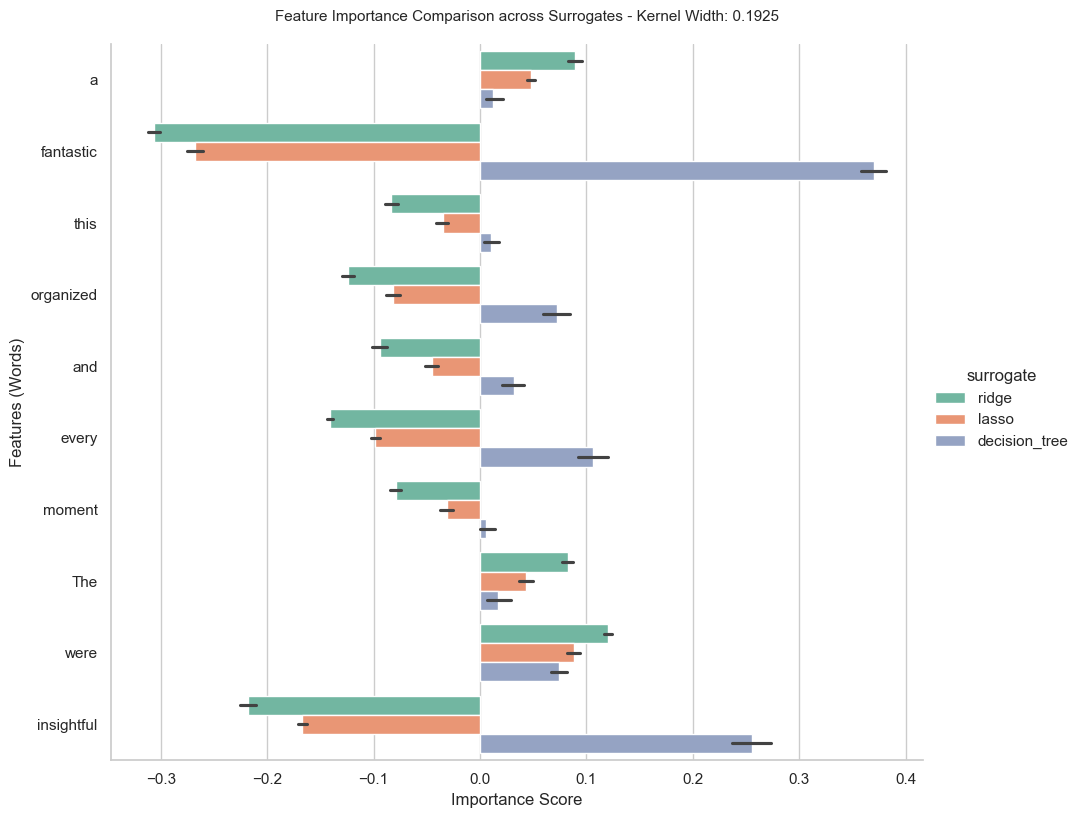

In [83]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load  data
df_surrogates_clean = pd.read_csv('/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/lime_surrogates_kernel_results.csv')


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Aggregation and Filtering
top_words = (
    df_surrogates_clean.groupby('word')['importance']
    .apply(lambda x: x.abs().mean())
    .sort_values(ascending=False)
    .head(10)
    .index
)
df_filtered = df_surrogates_clean[df_surrogates_clean['word'].isin(top_words)]

# Visualization
sns.set_theme(style="whitegrid")

# sns.catplot returns a FacetGrid object (g), not a standard Axes object
g = sns.catplot(
    data=df_filtered,
    kind='bar',
    x='importance',    # Horizontal bars (swap x and y for vertical)
    y='word',
    hue='surrogate',
    height=8,
    aspect=1.2,
    palette='Set2',
    legend=True        # Built-in legend handling
)

# Customizing the plot via the FacetGrid 'g'
kernel_val = df_surrogates_clean['kernel_width'].iloc[0]

g.set_axis_labels("Importance Score", "Features (Words)")
g.fig.suptitle(f'Feature Importance Comparison across Surrogates - Kernel Width: {kernel_val}',
               fontsize=11, y=1.02)

plt.xticks(rotation=0)

plt.show()

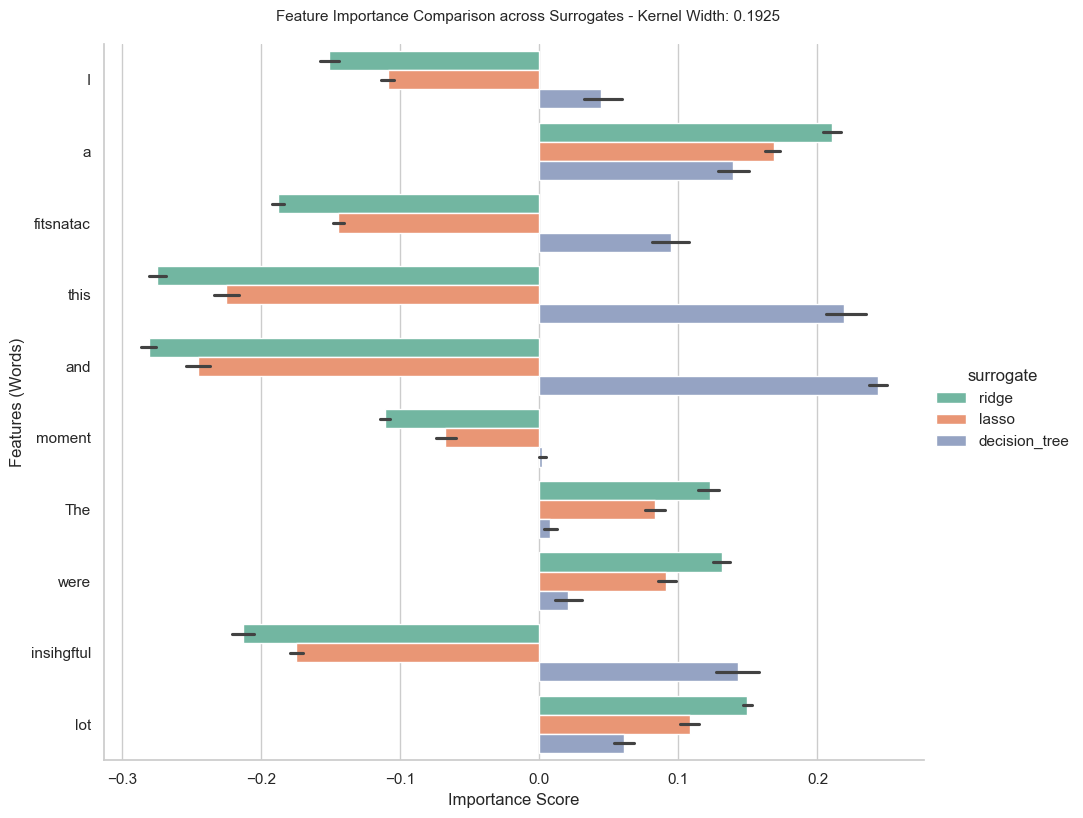

In [90]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df_surrogates_noisy = pd.read_csv('/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/lime_perturb_surrogates_kernel_results.csv')

top_words = (
    df_surrogates_noisy.groupby('word')['importance']
    .apply(lambda x: x.abs().mean())
    .sort_values(ascending=False)
    .head(10)
    .index
)
df_filtered = df_surrogates_noisy[df_surrogates_noisy['word'].isin(top_words)]

# Visualization
sns.set_theme(style="whitegrid")

# sns.catplot returns a FacetGrid object (g), not a standard Axes object
g = sns.catplot(
    data=df_filtered,
    kind='bar',
    x='importance',    # Horizontal bars (swap x and y for vertical)
    y='word',
    hue='surrogate',
    height=8,
    aspect=1.2,
    palette='Set2',
    legend=True        # Built-in legend handling
)

# Customizing the plot via the FacetGrid 'g'
kernel_val = df_surrogates_noisy['kernel_width'].iloc[0]

g.set_axis_labels("Importance Score", "Features (Words)")
g.fig.suptitle(f'Feature Importance Comparison across Surrogates - Kernel Width: {kernel_val}',
               fontsize=11, y=1.02)

# If you want to rotate labels (though less necessary for horizontal bars):
plt.xticks(rotation=0)

plt.show()

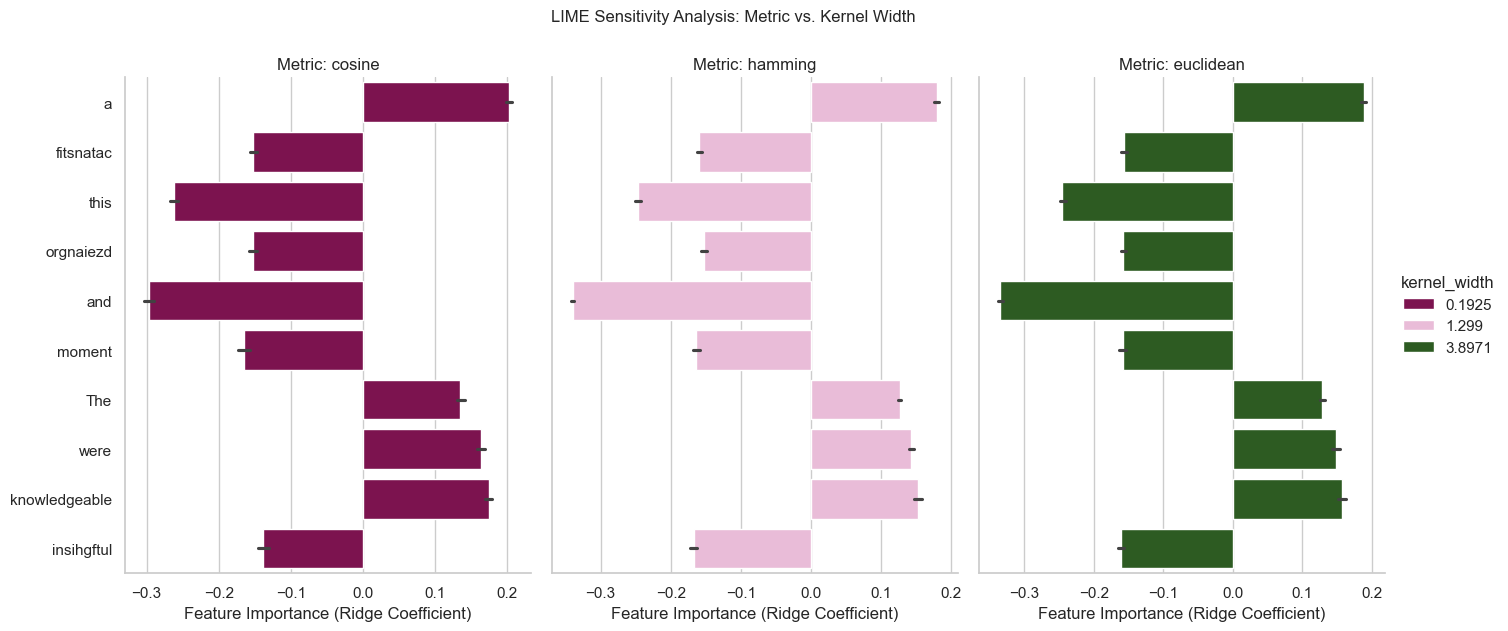

In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df_lhs = pd.read_csv('/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/lime_perturb_lhs_sampling_kernel_results.csv')

# 2. Filtering for Readability
# LIME can generate many words. We'll pick the top 10 most influential
# words based on average absolute importance to keep the plot clean.
top_words = (
    df_lhs.groupby('word')['importance']
    .apply(lambda x: x.abs().mean())
    .sort_values(ascending=False)
    .head(10)
    .index
)
df_filtered = df_lhs[df_lhs['word'].isin(top_words)]

# 3. Create the Visualization
# We use 'catplot' to create a grid: one column per Metric
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df_filtered,
    kind="bar",
    x="importance",
    y="word",
    hue="kernel_width",
    col="metric",
    palette="PiYG",
    height=6,
    aspect=0.8,
    sharex=False # Allows each metric to show its own scale if they vary wildly
)

# 4. Customizing Labels and Titles
g.set_axis_labels("Feature Importance (Ridge Coefficient)", "")
g.set_titles("Metric: {col_name}")
g.fig.suptitle("LIME Sensitivity Analysis: Metric vs. Kernel Width", y=1.05, fontsize=12)

plt.show()



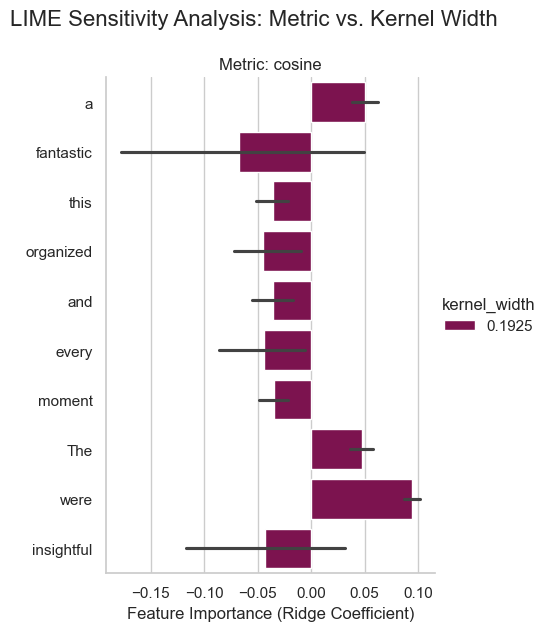

In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df_lhs = pd.read_csv('/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/lime_surrogates_kernel_results.csv')

# 2. Filtering for Readability
# LIME can generate many words. We'll pick the top 10 most influential
# words based on average absolute importance to keep the plot clean.
top_words = (
    df_lhs.groupby('word')['importance']
    .apply(lambda x: x.abs().mean())
    .sort_values(ascending=False)
    .head(10)
    .index
)
df_filtered = df_lhs[df_lhs['word'].isin(top_words)]

# 3. Create the Visualization
# We use 'catplot' to create a grid: one column per Metric
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df_filtered,
    kind="bar",
    x="importance",
    y="word",
    hue="kernel_width",
    col="metric",
    palette="PiYG",
    height=6,
    aspect=0.8,
    sharex=False # Allows each metric to show its own scale if they vary wildly
)

# 4. Customizing Labels and Titles
g.set_axis_labels("Feature Importance (Ridge Coefficient)", "")
g.set_titles("Metric: {col_name}")
g.fig.suptitle("LIME Sensitivity Analysis: Metric vs. Kernel Width", y=1.05, fontsize=16)

plt.show()



In [81]:
import pandas as pd

# 1. Load both
df_clean = pd.read_csv('/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/data/processed.csv')
df_noisy = pd.read_csv('/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/data/noisy.csv')

# 2. Merge them on a common ID or simply join if they are ordered the same
# We create a 'comparison_df'
comparison_df = pd.DataFrame({
    'clean_text': df_clean['review'],
    'noisy_text': df_noisy['review'],
    'label': df_clean['sentiment'] # labels should be the same
})

# Save this for your analytical experiments
comparison_df.to_csv('/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/data/analytical.csv', index=False)

In [90]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

file1 = "/Users/oumaymabamoh/PycharmProjects/thesis-evaluation-synthetic-data-lime-nlp/notebooks/lime_evaluation/lime_stability_experiment.csv"

file2 = "/Users/oumaymabamoh/PycharmProjects/thesis-evaluation-synthetic-data-lime-nlp/notebooks/lime_evaluation/perturb_lime_stability_experiment.csv"

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

import pandas as pd

def calculate_jaccard(df1, df2, top_k=10):
    # 1. Identify the top K features for each run
    set1 = set(df1.nlargest(top_k, 'weight')['feature'].str.lower())
    set2 = set(df2.nlargest(top_k, 'weight')['feature'].str.lower())

    # 2. Calculate Intersection and Union
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))

    # 3. Compute Index
    jaccard_score = intersection / union

    return jaccard_score, set1.intersection(set2)

# --- EXAMPLE USAGE ---
# Let's say your dataframes look like this:
# df1: ['A', 'B', 'C', 'D'], df2: ['A', 'C', 'E', 'F']

score, common = calculate_jaccard(df1, df2, top_k=10)

print(f"Jaccard Stability Score: {score:.2f}")
print(f"Features that stayed in the top list: {common}")

Jaccard Stability Score: 0.00
Features that stayed in the top list: set()


In [94]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import product

file_path = "/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/lime_surrogates_kernel_results.csv"

df_surrogate = pd.read_csv(file_path)

# 2. Create a unique 'config' label for each run
# 2. Create the 'config' column explicitly # This combines the metadata into a single string label for the heatmap
df_surrogate['config'] = ( df_surrogate['surrogate'] + "_" + df_surrogate['sampler'] + "_" + df_surrogate['kernel_width'].astype(str) )

def calculate_jaccard_matrix(df_surrogate, top_k=5):
    configs = df_surrogate['config'].unique()
    n = len(configs)
    jaccard_matrix = np.zeros((n, n))

    # Get the top K words for each configuration
    top_words_dict = {}
    for config in configs:
        top_words = set(df_surrogate[df_surrogate['config'] == config]
                        .sort_values(by='importance', ascending=False)
                        .head(top_k)['word'])
        top_words_dict[config] = top_words

    # Calculate Jaccard: |A ∩ B| / |A ∪ B|
    for i, conf_a in enumerate(configs):
        for j, conf_b in enumerate(configs):
            set_a = top_words_dict[conf_a]
            set_b = top_words_dict[conf_b]

            intersection = len(set_a.intersection(set_b))
            union = len(set_a.union(set_b))
            jaccard_matrix[i, j] = intersection / union if union > 0 else 0

    return pd.DataFrame(jaccard_matrix, index=configs, columns=configs)

# 3. Compute and Plot
df_surrogate = calculate_jaccard_matrix(df_surrogate, top_k=5)

plt.figure(figsize=(12, 10))
sns.heatmap(df_surrogate, annot=True, cmap='RdPu', fmt=".2f")
plt.title("Jaccard Similarity of Top 5 Important Words")
plt.ylabel("Configuration (Sampler_Model_Width)")
plt.xlabel("Configuration (Sampler_Model_Width)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

KeyError: 'sampler'